<h3>Purpose:</h3>

This notebook tains a Convolutional Neural Network (CNN) to classify <br>
medical images as benign (non-cancerous) or malignant (cancerous).

This notebook: <br>
1. Loads and preprocesses image data from the dataset folders. <br>
2. Applies data augmentation to improve generalisation. <br>
3. Builds a CNN model for image classification. <br>
4. Trains the model using training and validation datasets. <br>
5. Evaluates model performance. <br>
6. Saves the trained model for later usage.

In [11]:
# This lets us work with folders and files on the computer.
import os

# This helps us work with numbers and big lists of numbers.
import numpy as np

# This lets us draw graphs and pictures.
import matplotlib.pyplot as plt

# This is the main tool we use to build and train our AI.
import tensorflow as tf

# This helps us load images and prepare them for the AI.
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# These are the building blocks of our AI model.
from tensorflow.keras import layers, models

# These help us stop training at the right time and save progress.
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

<h3>Configuration</h3>

In [13]:
# This is where the training pictures are stored.
train_dir = './../data/train'

# This is where the validation (test) pictures are stored.
validation_dir = './../data/validation'

# This is where we will save our trained AI.
output_dir = './../outputs'

# This creates the folder if it does not already exist.
os.makedirs(output_dir, exist_ok=True)

# This sets the size of each image (like resizing a photo).
IMG_SIZE = (150, 150)

# This is how many images the AI looks at at one time.
BATCH_SIZE = 32

# This is how many times the AI will go through all the images.
EPOCHS = 20

<h3>Data Generators</h3>

In [14]:
# This tool feeds images to the AI while it is learning.

# It also:
# - makes images smaller numbers (easier for AI)
# - slightly changes images to help the AI learn better

train_datagen = ImageDataGenerator(
    rescale=1./255,          # Makes pixel numbers smaller and easier to learn
    rotation_range=20,       # Slightly rotates images
    width_shift_range=0.2,   # Moves images left and right
    height_shift_range=0.2,  # Moves images up and down
    shear_range=0.15,        # Tilts images a little
    zoom_range=0.2,          # Zooms in and out
    horizontal_flip=True     # Flips images like a mirror
)

# This one only prepares images without changing them.
validation_datagen = ImageDataGenerator(rescale=1./255)

<h3>Load the Data</h3>

In [15]:
# This loads the training images from folders.
# The folder names tell the AI what is "good" or "bad".
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# This loads the validation images.
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# This shows which folder is which label.
print("\ntrain_generator.class_indices:", train_generator.class_indices)

Found 1998 images belonging to 2 classes.
Found 501 images belonging to 2 classes.

train_generator.class_indices: {'benign': 0, 'malignant': 1}


<h3>Build the Model</h3>

In [16]:
# Now we build the AI "brain".
# It learns by looking at pictures again and again.

model = models.Sequential([
    # This layer looks for simple patterns like edges.
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),

    # This shrinks the image but keeps important parts.
    layers.MaxPooling2D(2, 2),

    # This layer finds more detailed patterns.
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # This layer finds even more complex shapes.
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # This flattens everything into a list of numbers.
    layers.Flatten(),

    # This layer helps the AI make decisions.
    layers.Dense(128, activation='relu'),

    # This helps prevent the AI from memorizing too much.
    layers.Dropout(0.5),

    # This gives the final answer (0 or 1).
    layers.Dense(1, activation='sigmoid')
])

<h3>Compile the Model</h3>

In [17]:
# This tells the AI how to learn and how to measure mistakes.
model.compile(
    optimizer='adam',                 # How the AI improves itself
    loss='binary_crossentropy',       # How wrong the AI is
    metrics=['accuracy']              # How often it is correct
)

# This prints the structure of the AI.
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

<h3>Callbacks</h3>

In [18]:
# This stops training if the AI stops improving.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# This saves the best version of the AI while training.
checkpoint = ModelCheckpoint(
    filepath=os.path.join(output_dir, 'best_model.h5'),
    monitor='val_loss',
    save_best_only=True
)

<h3>Train the Model</h3>

In [19]:
# Now the AI starts learning from the images.
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.6380 - loss: 0.7040

63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 668ms/step - accuracy: 0.6937 - loss: 0.6172 - val_accuracy: 0.7285 - val_loss: 0.6275
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.7623 - loss: 0.5143

63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 574ms/step - accuracy: 0.7708 - loss: 0.5112 - val_accuracy: 0.7725 - val_loss: 0.5796
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 567ms/step - accuracy: 0.7618 - loss: 0.5209 - val_accuracy: 0.6906 - val_loss: 0.6176
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 36s 572ms/step - accuracy: 0.8038 - loss: 0.4850 - val_accuracy: 0.7705 - val_loss: 0.6115
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.7954 - loss: 0.4949

63/63 ━━━━━━━━━━━━━━━━━━━━ 35s 548ms/step - accuracy: 0.8043 - loss: 0.4739 - val_accuracy: 0.7405 - val_loss: 0.5652
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 526ms/step - accuracy: 0.7768 - loss: 0.5085 - val_accuracy: 0.6228 - val_loss: 0.7204
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 533ms/step - accuracy: 0.8128 - loss: 0.4560 - val_accuracy: 0.6248 - val_loss: 0.7669
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 34s 529ms/step - accuracy: 0.8153 - loss: 0.4525 - val_accuracy: 0.5649 - val_loss: 1.6011
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 527ms/step - accuracy: 0.7873 - loss: 0.4951 - val_accuracy: 0.5569 - val_loss: 0.8168
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 525ms/step - accuracy: 0.8093 - loss: 0.4697 - val_accuracy: 0.7186 - val_loss: 0.5715


<h3>Save the Model</h3>

In [20]:
# This saves the final trained AI to a file.
model.save(os.path.join(output_dir, 'final_model.h5'))

<h3>Plot the Training Results</h3>

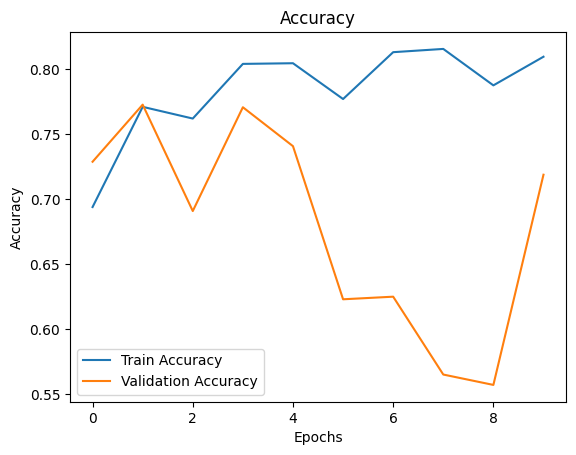

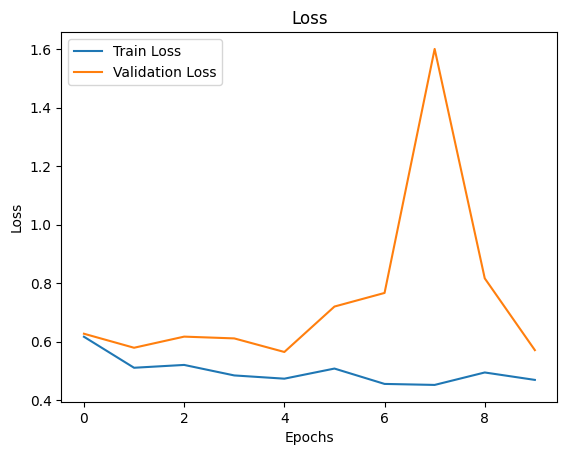

In [21]:
# This shows how good the AI got over time.

# Accuracy graph
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

# Loss graph (how many mistakes it made)
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

<h3>Evaluate the Model</h3>

In [22]:
# This tests how well the AI performs on new images.
val_loss, val_accuracy = model.evaluate(validation_generator)

# This prints the final results.
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy {val_accuracy:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step - accuracy: 0.7405 - loss: 0.5652
Validation Loss: 0.5652
Validation Accuracy 0.7405
